In [ ]:
import pandas
import matplotlib.pyplot as plt
import numpy as np


In [38]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [5]:
df = pandas.read_csv("agri_data.csv")
print(df.head())

                         State                  District      Crop     Year  \
0  Andaman and Nicobar Islands                  NICOBARS  Arecanut  2001-02   
1  Andaman and Nicobar Islands                  NICOBARS  Arecanut  2002-03   
2  Andaman and Nicobar Islands                  NICOBARS  Arecanut  2003-04   
3  Andaman and Nicobar Islands  NORTH AND MIDDLE ANDAMAN  Arecanut  2001-02   
4  Andaman and Nicobar Islands            SOUTH ANDAMANS  Arecanut  2002-03   

       Season    Area Area Units  Production Production Units     Yield  
0      Kharif  1254.0    Hectare      2061.0           Tonnes  1.643541  
1  Whole Year  1258.0    Hectare      2083.0           Tonnes  1.655803  
2  Whole Year  1261.0    Hectare      1525.0           Tonnes  1.209358  
3      Kharif  3100.0    Hectare      5239.0           Tonnes  1.690000  
4  Whole Year  3105.0    Hectare      5267.0           Tonnes  1.696296  


In [7]:
x = df.iloc[:, 0]
y = df.iloc[:, 1]

In [14]:
def generate_state_code(state):
    words = state.lower().split()

    if(len(words) == 1):
        return words[0][0].upper()
    else:
        return ''.join(word[0].upper() for word in words).upper()

df['State_Code'] = df['State'].apply(generate_state_code)
print(df.head())    
    

                         State                  District      Crop     Year  \
0  Andaman and Nicobar Islands                  NICOBARS  Arecanut  2001-02   
1  Andaman and Nicobar Islands                  NICOBARS  Arecanut  2002-03   
2  Andaman and Nicobar Islands                  NICOBARS  Arecanut  2003-04   
3  Andaman and Nicobar Islands  NORTH AND MIDDLE ANDAMAN  Arecanut  2001-02   
4  Andaman and Nicobar Islands            SOUTH ANDAMANS  Arecanut  2002-03   

       Season    Area Area Units  Production Production Units     Yield  \
0      Kharif  1254.0    Hectare      2061.0           Tonnes  1.643541   
1  Whole Year  1258.0    Hectare      2083.0           Tonnes  1.655803   
2  Whole Year  1261.0    Hectare      1525.0           Tonnes  1.209358   
3      Kharif  3100.0    Hectare      5239.0           Tonnes  1.690000   
4  Whole Year  3105.0    Hectare      5267.0           Tonnes  1.696296   

  State_Code  
0       AANI  
1       AANI  
2       AANI  
3       AANI  

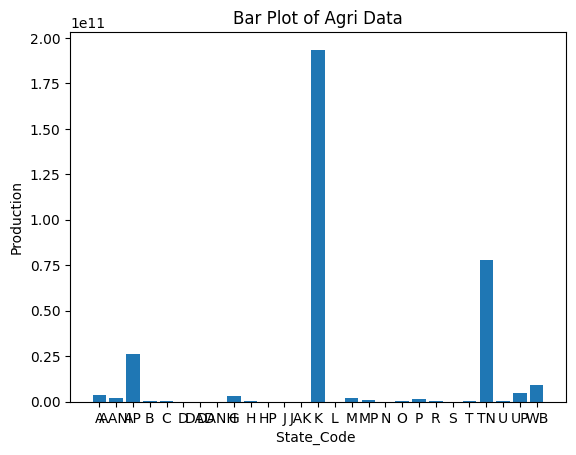

In [19]:
state_production = df.groupby('State_Code')['Production'].sum()

plt.bar(state_production.index, state_production.values)
plt.xlabel("State_Code ")
plt.ylabel("Production")
plt.title("Bar Plot of Agri Data")
plt.show(
)



In [27]:
print(df.shape)
print(df.columns)
print(df['Production Units'].unique())  
print(df['Crop'].unique())

(345407, 9)
Index(['State', 'District', 'Crop', 'Year', 'Season', 'Area', 'Production',
       'Production Units', 'Yield'],
      dtype='str')
<StringArray>
['Tonnes', 'Nuts', 'Bales']
Length: 3, dtype: str
<StringArray>
[             'Arecanut',                'Banana',          'Black pepper',
             'Cashewnut',               'Coconut',          'Dry chillies',
                'Ginger',   'Other Kharif pulses',        'other oilseeds',
                  'Rice',             'Sugarcane',          'Sweet potato',
             'Arhar/Tur',                 'Bajra',           'Castor seed',
             'Coriander',          'Cotton(lint)',                  'Gram',
             'Groundnut',            'Horse-gram',                 'Jowar',
               'Linseed',                 'Maize',                 'Mesta',
     'Moong(Green Gram)',            'Niger seed',                 'Onion',
     'Other Rabi pulses',                'Potato',                  'Ragi',
     'Rapeseed &Mu

11 features we Have Here , from which we have to eliminate state code and area unit as it consistent as hectare in all 

let's do one thing let's neutralize production units to one single tonnes from ['Tonnes', 'Nuts', 'Bales']
Length: 3, dtype: str by change that row production value too wrt to units

let's leave this it's complicated to convert that things 

In [30]:
df = df.drop(columns=[ 'District', 'Season'])
print(df.head())    

                         State      Crop     Year    Area  Production  \
0  Andaman and Nicobar Islands  Arecanut  2001-02  1254.0      2061.0   
1  Andaman and Nicobar Islands  Arecanut  2002-03  1258.0      2083.0   
2  Andaman and Nicobar Islands  Arecanut  2003-04  1261.0      1525.0   
3  Andaman and Nicobar Islands  Arecanut  2001-02  3100.0      5239.0   
4  Andaman and Nicobar Islands  Arecanut  2002-03  3105.0      5267.0   

  Production Units     Yield  
0           Tonnes  1.643541  
1           Tonnes  1.655803  
2           Tonnes  1.209358  
3           Tonnes  1.690000  
4           Tonnes  1.696296  


Drop rows where Yield is null or zero (bad records) or fix it .

In [33]:
df['Yield'] = pandas.to_numeric(df['Yield'], errors='coerce')
df['Production'] = pandas.to_numeric(df['Production'], errors='coerce') 
df['Area'] = pandas.to_numeric(df['Area'], errors='coerce')

bad_Yield = df['Yield'].isna() | df['Yield'] == 0
print(df[bad_Yield])
can_compute = df['Production'].notna() & df['Area'].notna() &(df['Area']!= 0)
df.loc[bad_Yield & can_compute, 'Yield'] = df['Production']/ df['Area']

df = df.dropna(subset=['Yield'])
df = df[df['Yield']!=0]

Empty DataFrame
Columns: [State, Crop, Year, Area, Production, Production Units, Yield]
Index: []


Parse Year into a usable integer , # Taking first year as base year for consistency

In [ ]:
df['Year'] = df['Year'].str[:4].astype(int)

print(df.head())


                         State      Crop  Year    Area  Production  \
0  Andaman and Nicobar Islands  Arecanut  2001  1254.0      2061.0   
1  Andaman and Nicobar Islands  Arecanut  2002  1258.0      2083.0   
2  Andaman and Nicobar Islands  Arecanut  2003  1261.0      1525.0   
3  Andaman and Nicobar Islands  Arecanut  2001  3100.0      5239.0   
4  Andaman and Nicobar Islands  Arecanut  2002  3105.0      5267.0   

  Production Units     Yield  
0           Tonnes  1.643541  
1           Tonnes  1.655803  
2           Tonnes  1.209358  
3           Tonnes  1.690000  
4           Tonnes  1.696296  


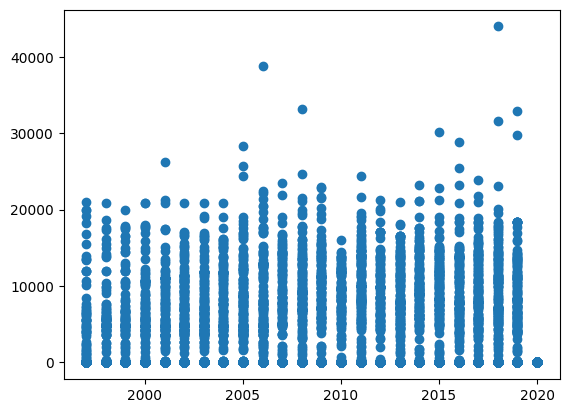

In [36]:
plt.scatter(df['Year'], df['Yield'])
plt.show()

In [44]:
# force encode all string columns
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
 
# remove extreme yield outliers (top 1%)
p99 = df['Yield'].quantile(0.99)
df = df[df['Yield'] <= p99].copy()
print(f"After outlier removal — rows: {len(df)}, max yield: {df['Yield'].max():.2f}")
 
# log transform the target — compresses the skewed range
y_raw = df['Yield'].values.astype(float)
y = np.log1p(y_raw)   # log1p = log(1 + x), safe for zeros
 
# features
features = [col for col in ['State', 'Crop', 'Year', 'Area'] if col in df.columns]
X = df[features].values.astype(float)
 
# normalize X
X_min = X.min(axis=0)
X_max = X.max(axis=0)
X = (X - X_min) / (X_max - X_min + 1e-8)
 
# split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
y_test_raw = y_raw[split:]   # keep original scale for RMSE reporting
 
print(f"Training: {len(X_train)} rows | Test: {len(X_test)} rows")

After outlier removal — rows: 335996, max yield: 107.02
Training: 268796 rows | Test: 67200 rows


2. Build the Engine (pure numpy)
Three functions written from scratch:

Forward pass — multiply inputs by weights, add bias, output a prediction 
Loss function — Mean Squared Error between prediction and actual yield
Gradient computation — how much to adjust each weight to reduce loss
One training loop that runs these three functions thousands of times, nudging weights slightly each iteration. That nudge is the learning rate. That loop is gradient descent.

In [47]:

def forward(X, w, b):
    return X @ w + b
 
def mse_loss(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)
 
def compute_gradients(X, y_pred, y_true):
    error = y_pred - y_true
    dw = (2 / len(X)) * (X.T @ error)
    db = (2 / len(X)) * np.sum(error)
    return dw, db
 
def train(X, y, lr=0.1, epochs=2000):
    w = np.zeros(X.shape[1])
    b = 0.0
    losses = []
    for i in range(epochs):
        y_pred = forward(X, w, b)
        loss = mse_loss(y_pred, y)
        dw, db = compute_gradients(X, y_pred, y)
        w -= lr * dw
        b -= lr * db
        losses.append(loss)
        if i % 200 == 0:
            print(f"epoch {i:4d}  |  loss: {loss:.6f}")
    return w, b, losses
 
print("\n── training ──")
w, b, losses = train(X_train, y_train, lr=0.3, epochs=5000)


── training ──
epoch    0  |  loss: 1.853290
epoch  200  |  loss: 0.778957
epoch  400  |  loss: 0.778957
epoch  600  |  loss: 0.778957
epoch  800  |  loss: 0.778957
epoch 1000  |  loss: 0.778957
epoch 1200  |  loss: 0.778957
epoch 1400  |  loss: 0.778957
epoch 1600  |  loss: 0.778957
epoch 1800  |  loss: 0.778957
epoch 2000  |  loss: 0.778957
epoch 2200  |  loss: 0.778957
epoch 2400  |  loss: 0.778957
epoch 2600  |  loss: 0.778957
epoch 2800  |  loss: 0.778957
epoch 3000  |  loss: 0.778957
epoch 3200  |  loss: 0.778957
epoch 3400  |  loss: 0.778957
epoch 3600  |  loss: 0.778957
epoch 3800  |  loss: 0.778957
epoch 4000  |  loss: 0.778957
epoch 4200  |  loss: 0.778957
epoch 4400  |  loss: 0.778957
epoch 4600  |  loss: 0.778957
epoch 4800  |  loss: 0.778957



Test RMSE (original scale): 11.75 Tonnes/Hectare


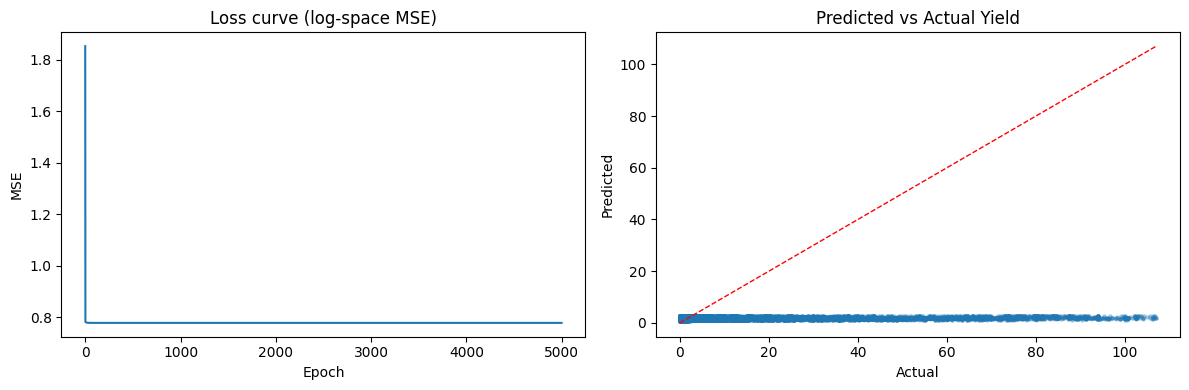

In [48]:

y_pred_log = forward(X_test, w, b)
y_pred_actual = np.expm1(y_pred_log)   # reverse the log transform
 
rmse = np.sqrt(np.mean((y_pred_actual - y_test_raw) ** 2))
print(f"\nTest RMSE (original scale): {rmse:.2f} Tonnes/Hectare")
 
# ── plots ─────────────────────────────────────────────────────────────────────
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
axes[0].plot(losses)
axes[0].set_title("Loss curve (log-space MSE)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
 
axes[1].scatter(y_test_raw, y_pred_actual, alpha=0.3, s=5)
axes[1].plot([y_test_raw.min(), y_test_raw.max()],
             [y_test_raw.min(), y_test_raw.max()], 'r--', lw=1)
axes[1].set_title("Predicted vs Actual Yield")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")
 
plt.tight_layout()
plt.show()

my linear model learned the average shape of the data but completely 
failed on high-yield crops. the relationship between crop type and yield 
is not linear — sugarcane yield and wheat yield live in completely 
different ranges. a single straight line cannot capture that.

this is why decision trees exist — they split the data by crop type 
first, then learn a separate pattern for each group.

RMSE dropped from 857 → 11.75 with log transform + outlier removal. but predictions still cluster near the mean. 
linear regression finds one global average line — it can't learn that wheat yields 3 T/Ha and rice yields 40 T/Ha because those need separate rules, not one equation. 